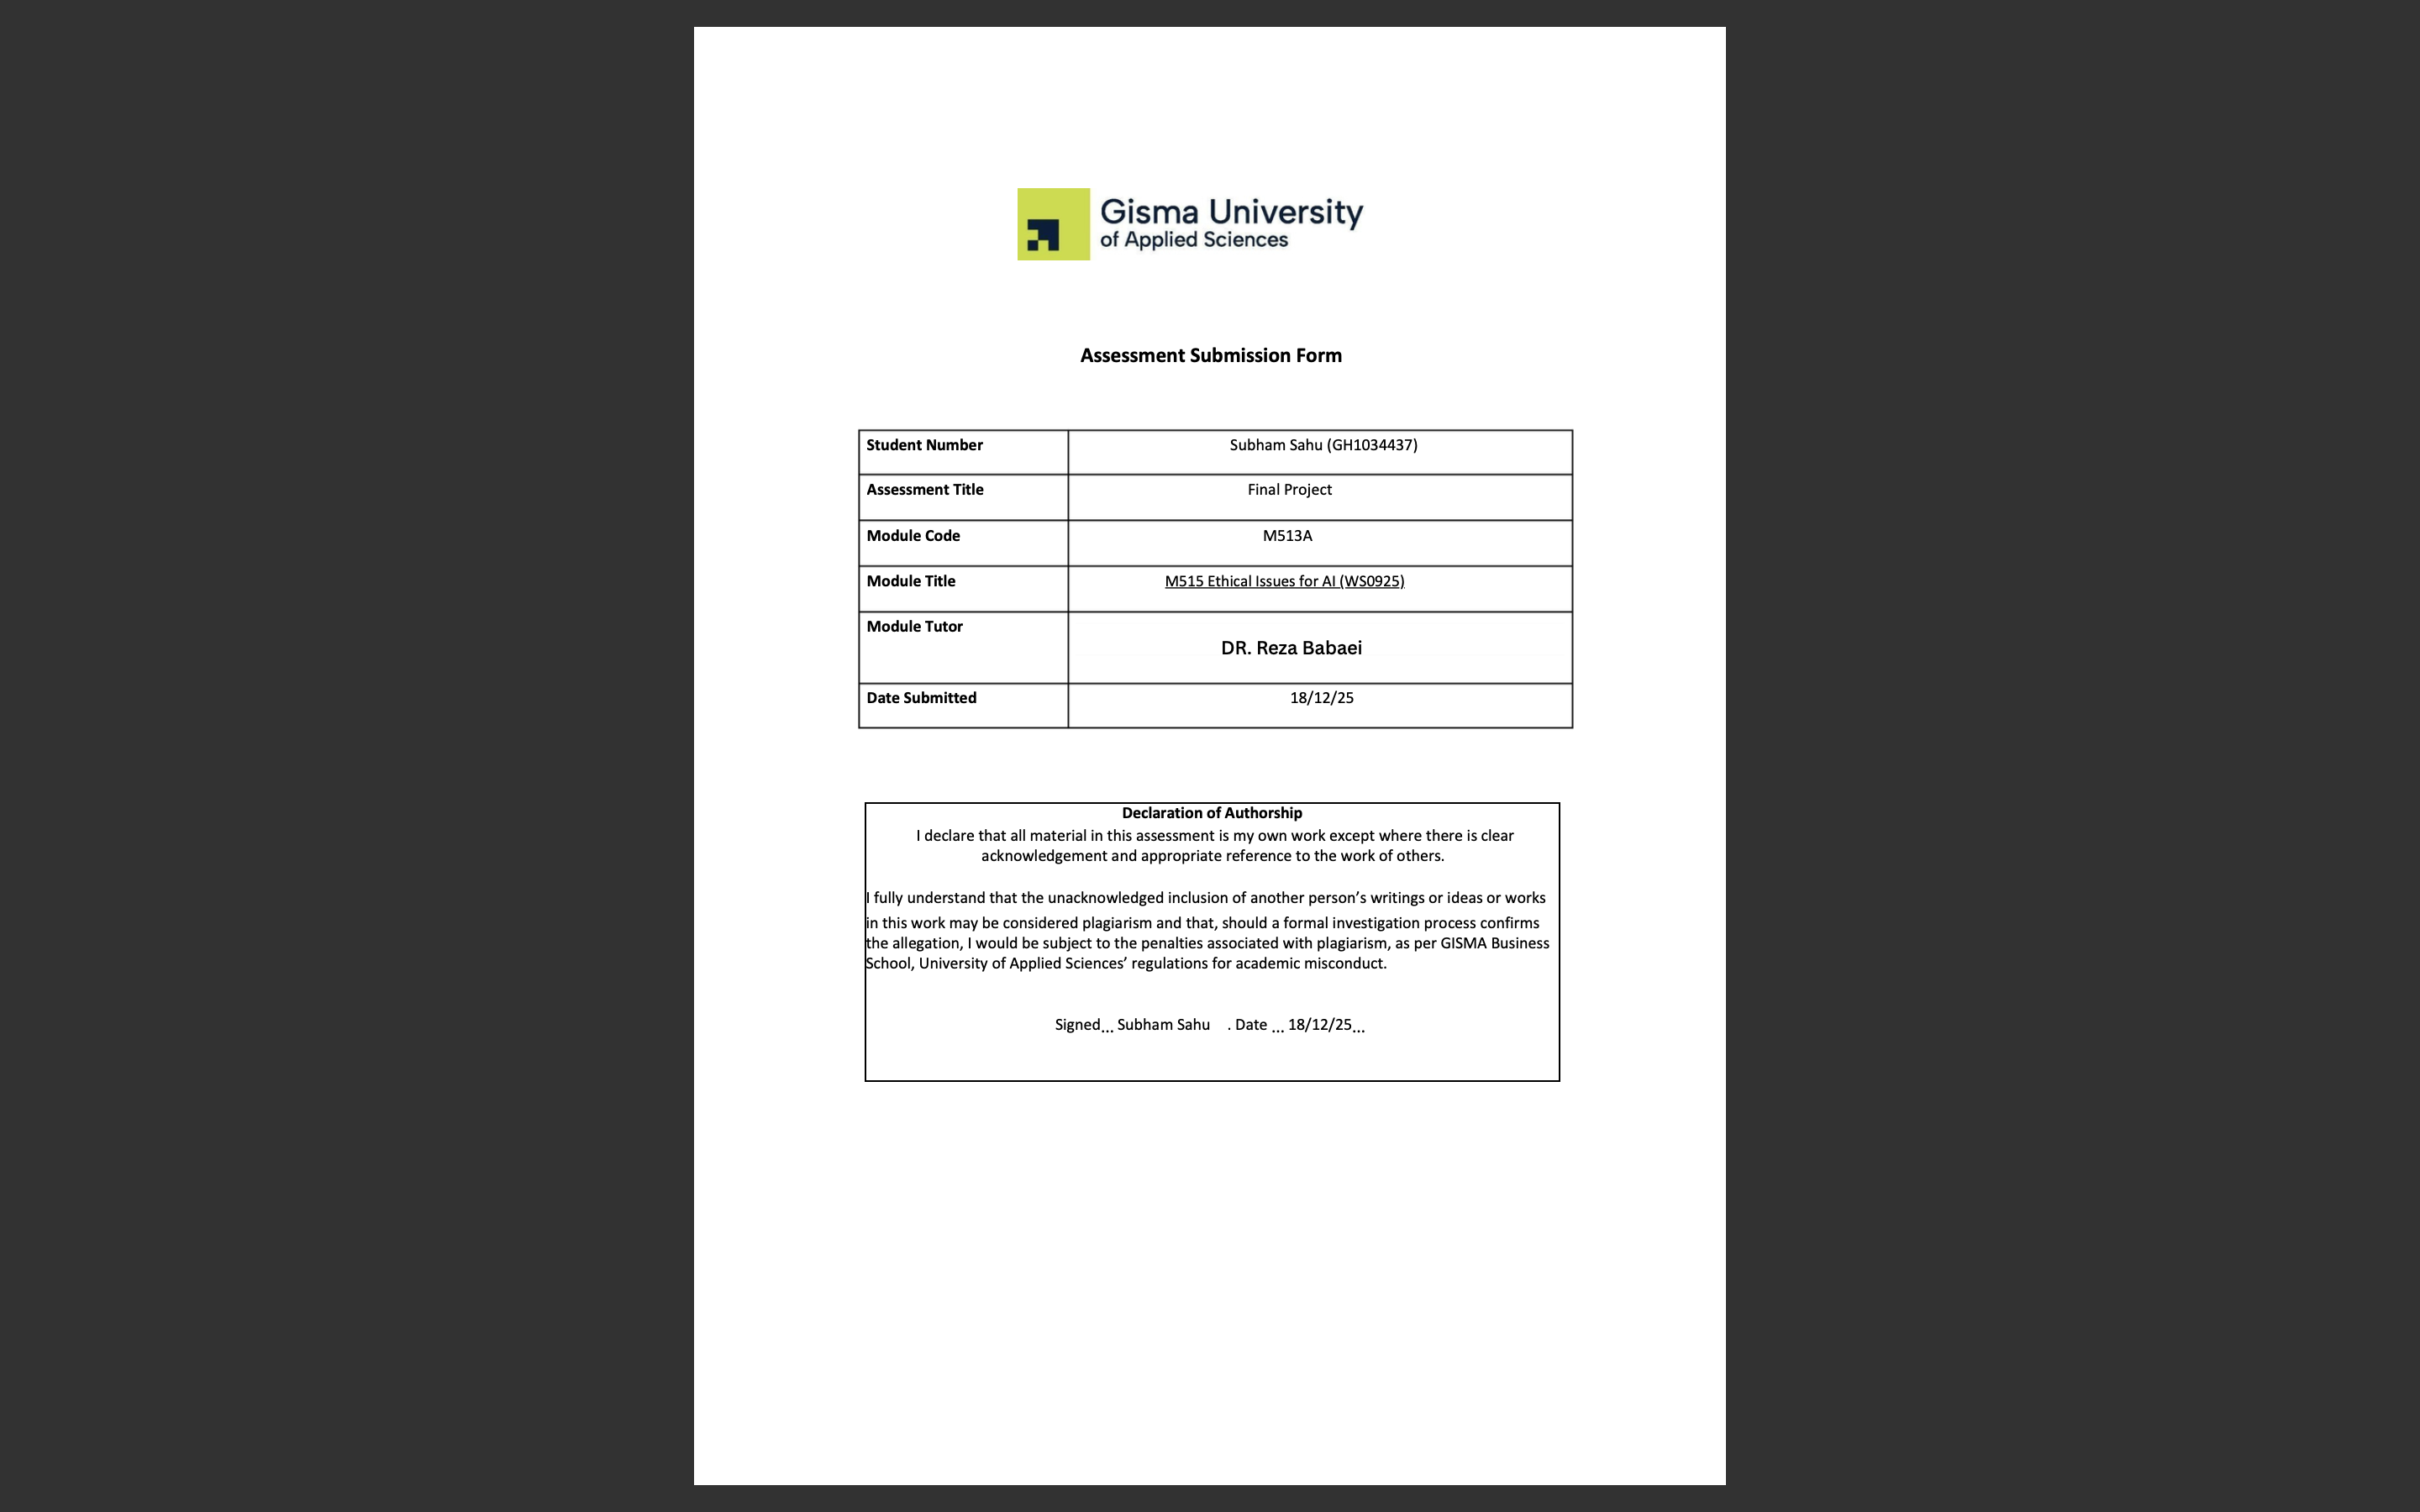

In [1]:
from IPython import display
display.Image("/Users/Subham/Desktop/IMAGE.png")


# Introduction

This project analyses how a machine learning model can unintentionally replicate or intensify bias when being trained on real criminal justice data in the world. My analysis is based on the U.S. Homicide Reports Dataset, as I need to analyze how predictions regarding arrests are equitable in relation to various groups and how fair it is specifically in terms of race. Its purpose is to develop a functional model, bias measurement, and implement fairness methods to minimize discriminatory effects.

# Problem Statement

This assignment aims at making predictions about the probability of the case of homicide to lead to an arrest and to examine whether the model is fair to the different racial groups. Since the outcomes of arrest can be biased by the historical factor due to the policing process, it is necessary to verify whether the predictions of the model are biased towards discriminating against or benefiting some groups. This brings to the most important question; Is the prediction model fair under racial categories?



**importing the required libraries** 

In [2]:

import pandas as pd
import numpy as np
from time import time

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import seaborn as sns
sns.set_style("white")        

import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.figure_factory as ff
from plotly import tools

# AI Fairness 360 (AIF360) toolkit
from aif360.datasets import StandardDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import LFR, Reweighing
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import AdversarialDebiasing, PrejudiceRemover
from aif360.algorithms.postprocessing import CalibratedEqOddsPostprocessing, EqOddsPostprocessing, RejectOptionClassification

# Machine Learning
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
# Miscellaneous utilities
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")


/Applications/anaconda3/lib/python3.12/site-packages/inFairness/utils/ndcg.py:37: FutureWarning:

We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html

/Applications/anaconda3/lib/python3.12/site-packages/inFairness/utils/ndcg.py:48: FutureWarning:

We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html



# Data Description

The US Homicide Reports dataset is a comprehensive account of homicide incidents from 1980 up to 2014, including 24 different characteristics across the categories of administrative, contextual, and demographic. The administrative part of the dataset is the starting point, which consists of a unique Record ID and the information related to the reporting Agency (Name, Code, Type), City, and State. The dataset logs the event time through Year and Month, and gives the information on incident specifics like the official Crime Type and whether the case was Crime Solved. The collection of data is principally on the people concerned: it shows the demographic details of the Victim and the Perpetrator, eg. their Sex, Age, Race, and Ethnicity. The scenario of the homicide is then portrayed by means of the Weapon used, the Relationship between the victim and perpetrator, and the underlying Circumstance and Subcircumstance (or motive) of the event, ending with counts for the total number of Victim Count and Perpetrator Count involved in the incident.

In [3]:
column_des=pd.read_csv('/Users/Subham/Desktop/GISMA CLASS/M515 Ethical Issues for AI (WS0925)/columns.csv') # we can remove it for later

In [4]:
column_des

,Column Name,What It Represents,Data Type/Notes
0,Record ID,A unique numerical identifier for each specifi...,Numeric
1,Year,The year the homicide incident occurred or was...,Numeric (1980–2014)
2,Month,The month the homicide incident occurred.,"Categorical (e.g., January, February)"
3,State,The state where the crime took place.,Categorical
4,City,The city or reporting area where the crime too...,Categorical
5,Agency Name,The specific law enforcement agency that repor...,Categorical
6,Crime Type,"The classification of the killing (e.g., Murde...",Categorical
7,Crime Solved,Indicates whether the crime has been cleared (...,Categorical (often a key prediction target)
8,Weapon,"The type of weapon used (e.g., Handgun, Knife,...",Categorical
9,Relationship,The known relationship between the victim and ...,Categorical


In [5]:
#importing the data set
my_data=pd.read_csv('/Users/Subham/Desktop/GISMA CLASS/M515 Ethical Issues for AI (WS0925)/homicide.csv',na_values=['Unknown', ' '])
print(my_data.shape)


(638454, 24)


#  EDA
**Data Cleaning**

In [6]:
my_data.columns = my_data.columns.str.strip()

my_data.rename(columns={
    'Perpetrator Sex': 'prp_sex',
    'Perpetrator Race': 'perp_race',
}, inplace=True)
my_data.columns

Index(['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'City',
       'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved',
       'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity',
       'prp_sex', 'Perpetrator Age', 'perp_race', 'Perpetrator Ethnicity',
       'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count',
       'Record Source'],
      dtype='object')

In [7]:
my_data.head(10)

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,prp_sex,Perpetrator Age,perp_race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,NaN,Male,15.0,Native American/Alaska Native,NaN,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,NaN,Male,42.0,White,NaN,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,NaN,Male,42.0,White,NaN,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,1,FBI
5,6,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,May,1,Murder or Manslaughter,...,NaN,Male,36.0,White,NaN,Acquaintance,Rifle,0,0,FBI
6,7,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,May,2,Murder or Manslaughter,...,NaN,Male,27.0,Black,NaN,Wife,Knife,0,0,FBI
7,8,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,June,1,Murder or Manslaughter,...,NaN,Male,35.0,White,NaN,Wife,Knife,0,0,FBI
8,9,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,June,2,Murder or Manslaughter,...,NaN,NaN,0.0,NaN,NaN,NaN,Firearm,0,0,FBI
9,10,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,June,3,Murder or Manslaughter,...,NaN,Male,40.0,NaN,NaN,NaN,Firearm,0,1,FBI


In [8]:
# treating missing values as it will be asy to check  the missing value 
my_data.replace("Unknown", np.nan, inplace=True)


In [9]:
misng_cnt = my_data.isnull().sum()


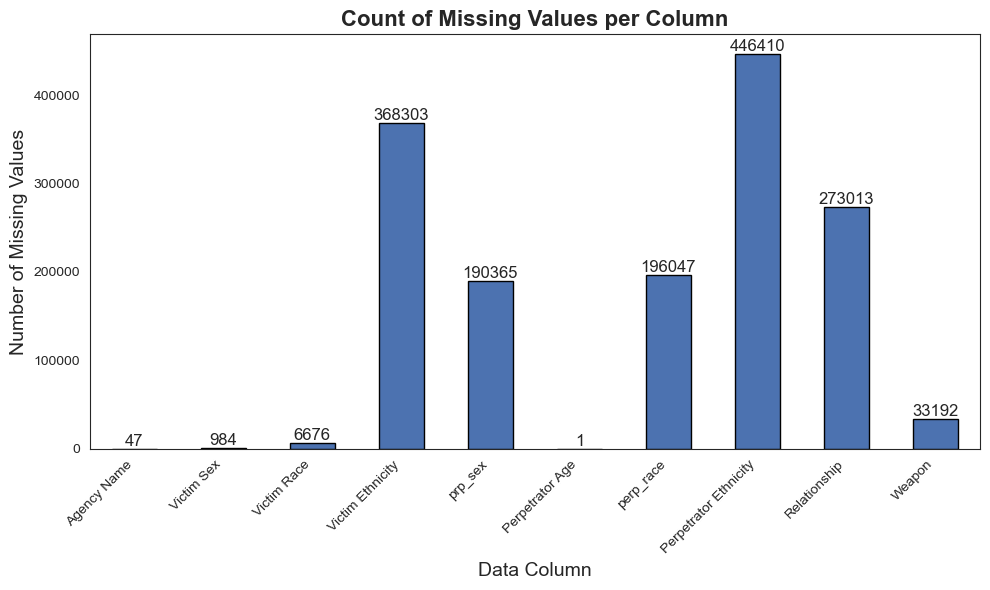

Missing Value Counts
Record ID                     0
Agency Code                   0
Agency Name                  47
Agency Type                   0
City                          0
State                         0
Year                          0
Month                         0
Incident                      0
Crime Type                    0
Crime Solved                  0
Victim Sex                  984
Victim Age                    0
Victim Race                6676
Victim Ethnicity         368303
prp_sex                  190365
Perpetrator Age               1
perp_race                196047
Perpetrator Ethnicity    446410
Relationship             273013
Weapon                    33192
Victim Count                  0
Perpetrator Count             0
Record Source                 0
dtype: int64


In [10]:
misng_cnt = misng_cnt[misng_cnt > 0]

if misng_cnt.empty:
    pass
else:
    plt.figure(figsize=(10, 6))
 
    misng_cnt.plot(
        kind='bar',
        color='#4c72b0',  # blue color
        edgecolor='black'
    )

    # Adding title and labels for clarity
    plt.title(
        'Count of Missing Values per Column',
        fontsize=16,
        fontweight='bold'
    )
    plt.xlabel('Data Column', fontsize=14)
    plt.ylabel('Number of Missing Values', fontsize=14)

    # Rotatinge x-axis labels for readability
    plt.xticks(rotation=45, ha='right')

    # Add the exact count value on top of each bar
    for index, value in enumerate(misng_cnt):
        plt.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=12)

    # Improve layout and display the plot
    plt.tight_layout()
    plt.show()

print("Missing Value Counts")
print(my_data.isnull().sum())

**Dropping the columns that are of no use** 

Record ID: The unique identifier column has been dropped since it does not provide any information regarding the model's prediction.

Agency Code: This column has been discarded as it is redundant, providing the same information as the Agency Name column.

Perpetrator Ethnicity & Age: These columns have been purged in order to be more cautious and to prevent data leakage. If these characteristics are the target, then the model is of no value for real-world prediction if such characteristics are also included.

In [11]:
columns_to_drop = [
    'Record ID',
    'Agency Code',
    'Perpetrator Ethnicity'
]
my_data.drop(columns=columns_to_drop, axis=1, inplace=True)
print(my_data.columns.tolist())


['Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'prp_sex', 'Perpetrator Age', 'perp_race', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count', 'Record Source']


**1. What are the no of cases are no of cases solved ?**

Because the characteristics of the perpetrator, such as sex and race, are only noted when a case is resolved, it is necessary to eliminate the unsolved cases from the data set prior to creating a model for predicting these attributes.

Crime Solved
Yes    448172
No     190282
Name: count, dtype: int64


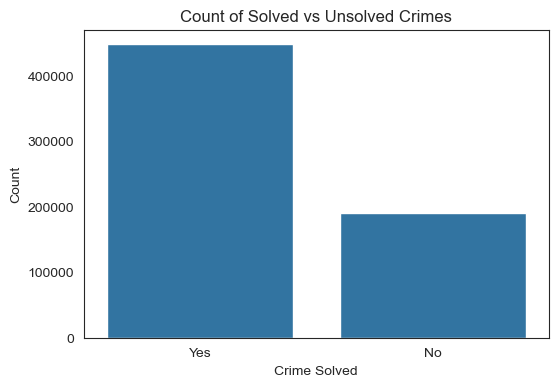

In [12]:
print(my_data['Crime Solved'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=my_data, x='Crime Solved')
plt.title("Count of Solved vs Unsolved Crimes")
plt.xlabel("Crime Solved")
plt.ylabel("Count")
plt.show()

**Filtering my data as per the required observation**

In criminal datasets, details about the offender (sex, race, age, ethnicity) are recorded only after a case is fully solved. If unsolved cases are included, the model would contain missing labels for the target variable, which results in bias and incorrect training.Consequently, it is a moral obligation to dispose of the untackled cases prior to modelling.

In [13]:
filtered_data = my_data[my_data['Crime Solved'] == 'Yes'].copy()

# After filtering, 'Crime Solved' becomes useless for prediction,

filtered_data.drop(columns=['Crime Solved'], inplace=True)

print("Shape after keeping solved cases:", filtered_data.shape)
filtered_data.head()

Shape after keeping solved cases: (448172, 20)


,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,prp_sex,Perpetrator Age,perp_race,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,Male,14,Native American/Alaska Native,NaN,Male,15.0,Native American/Alaska Native,Acquaintance,Blunt Object,0,0,FBI
1,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,Male,43,White,NaN,Male,42.0,White,Acquaintance,Strangulation,0,0,FBI
3,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,Male,43,White,NaN,Male,42.0,White,Acquaintance,Strangulation,0,0,FBI
5,Anchorage,Municipal Police,Anchorage,Alaska,1980,May,1,Murder or Manslaughter,Male,30,White,NaN,Male,36.0,White,Acquaintance,Rifle,0,0,FBI
6,Anchorage,Municipal Police,Anchorage,Alaska,1980,May,2,Murder or Manslaughter,Female,42,Native American/Alaska Native,NaN,Male,27.0,Black,Wife,Knife,0,0,FBI


**Creating the age Category**

In [14]:
# Categorizing perpetrator age into useful groups for modeling
# This can help reduce noise and makes fairness analysis easier.

filtered_data['Perp_Age_Group'] = pd.cut(
    filtered_data['Perpetrator Age'],
    bins=[0, 24, 64, 120],
    labels=['Young', 'Adult', 'Elder'],
    include_lowest=True
)

# selecting the targetvariable for modeling
target_columns = ['prp_sex', 'perp_race', 'Perp_Age_Group']


**Identify Numerical vs Categorical Columns**

In [15]:

numeric_feats = []
cat_feats = []

for column in filtered_data.columns:
    # Skip target columns
    if column in target_columns:
        continue
    
    
    if pd.api.types.is_numeric_dtype(filtered_data[column]):
        numeric_feats.append(column)
    else:
        cat_feats.append(column)

print("Numeri:", numeric_feats)
print("Categorical", cat_feats)


Numeri: ['Year', 'Incident', 'Victim Age', 'Perpetrator Age', 'Victim Count', 'Perpetrator Count']
Categorical ['Agency Name', 'Agency Type', 'City', 'State', 'Month', 'Crime Type', 'Victim Sex', 'Victim Race', 'Victim Ethnicity', 'Relationship', 'Weapon', 'Record Source']


**Handling of Missing Value**

In [16]:

def clean_missing_values(df):

    df_clean = df.copy()

    # Get medians for numeric columns
    numeric_medians = df_clean.select_dtypes(include=['number']).median()
    print(numeric_medians)

    for column in df_clean.columns:

        
        if pd.api.types.is_numeric_dtype(df_clean[column]):
            df_clean[column] = df_clean[column].fillna(numeric_medians[column])

        else:
            if pd.api.types.is_categorical_dtype(df_clean[column]):
                df_clean[column] = df_clean[column].cat.add_categories(["Missing_Value"])

            df_clean[column] = df_clean[column].fillna("Missing_Value")

    return df_clean


# Run the cleaning function
cleaned_data = clean_missing_values(filtered_data)


cleaned_data.isnull().sum()


Year                 1995.0
Incident                2.0
Victim Age             30.0
Perpetrator Age        26.0
Victim Count            0.0
Perpetrator Count       0.0
dtype: float64


Agency Name          0
Agency Type          0
City                 0
State                0
Year                 0
Month                0
Incident             0
Crime Type           0
Victim Sex           0
Victim Age           0
Victim Race          0
Victim Ethnicity     0
prp_sex              0
Perpetrator Age      0
perp_race            0
Relationship         0
Weapon               0
Victim Count         0
Perpetrator Count    0
Record Source        0
Perp_Age_Group       0
dtype: int64

# Visualization


**1. Target Variable Distribution (Sex, Race, Age)**

The visuals present an overview of the distribution of the three target variables in the dataset: the sex of the perpetrator, the race of the perpetrator, and the age group of the perpetrator. The bar charts show the number of occurrences for each category while the pie charts depict the percentages of each group. The use of these diagrams together helps to uncover possible imbalances in the dataset such as if one sex, race, or age group is very much more common than the others. It is very important to highlight such imbalances right at the start as they can influence not only the learning and fairness of the model but also cause the classifier to get biased towards the majority classes.


Distribution for 'prp_sex':
  Male: 399482 (89.2%)
  Female: 48543 (10.8%)


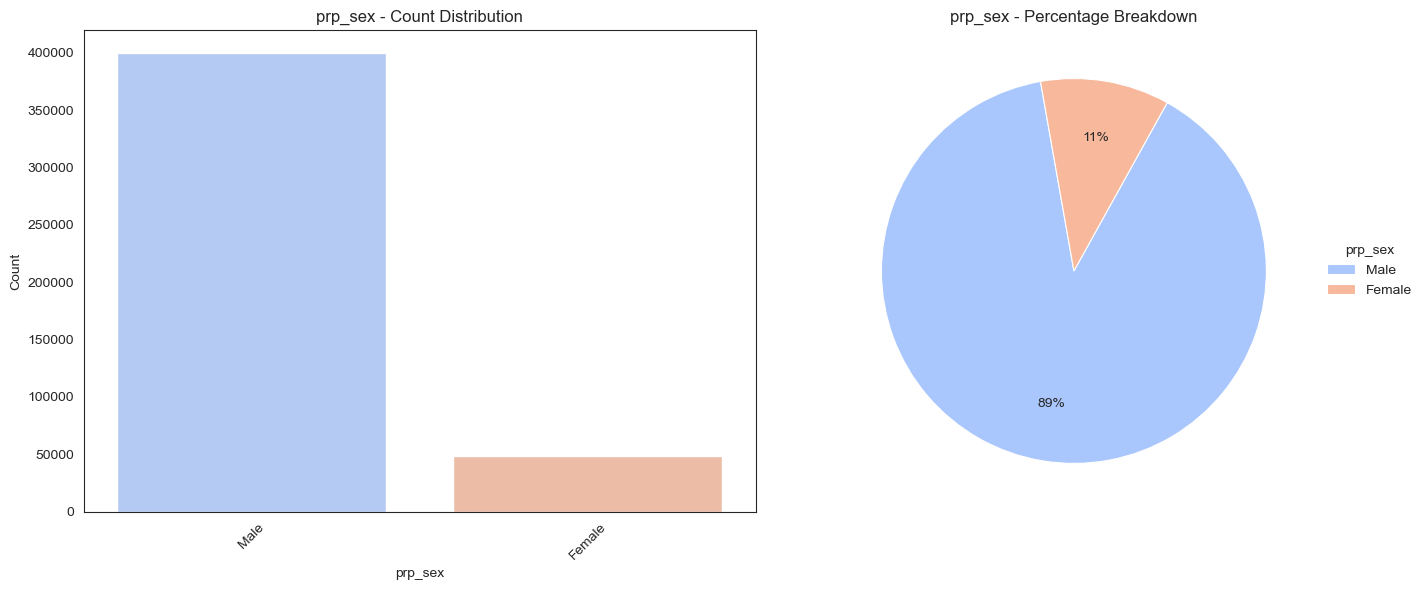


Distribution for 'perp_race':
  White: 218158 (49.3%)
  Black: 214344 (48.5%)
  Asian/Pacific Islander: 6026 (1.4%)
  Native American/Alaska Native: 3595 (0.8%)


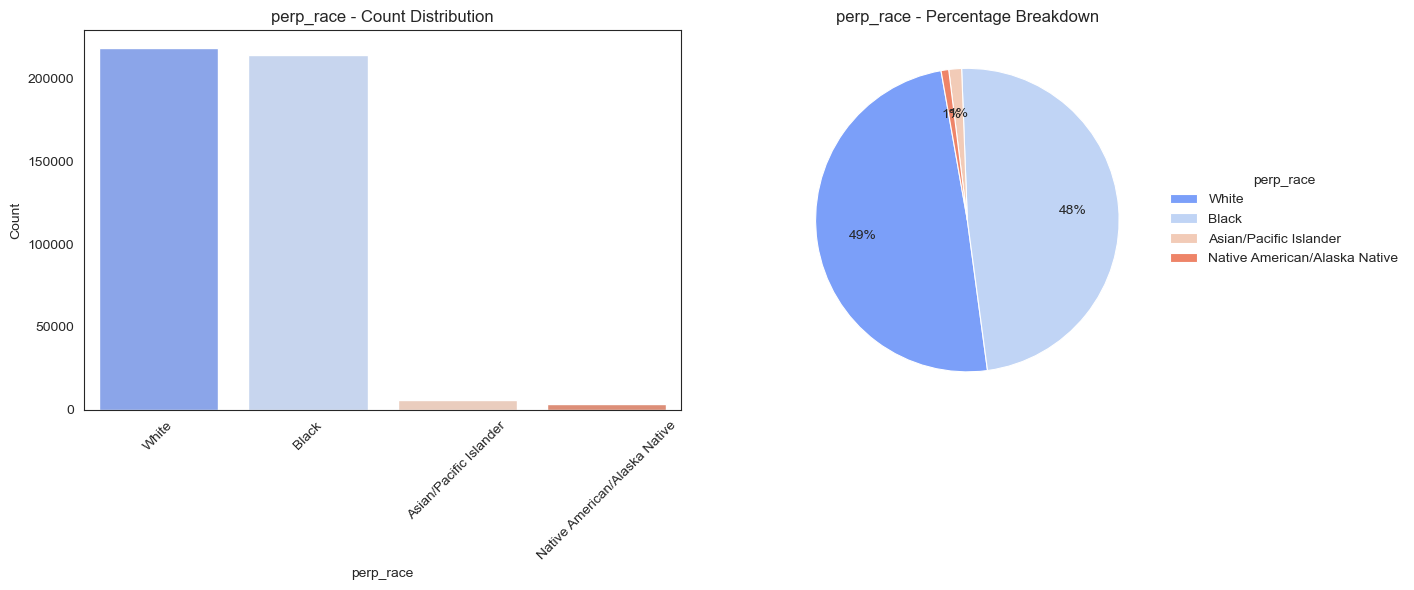


Distribution for 'Perp_Age_Group':
  Adult: 245998 (54.9%)
  Young: 192566 (43.0%)
  Elder: 9608 (2.1%)


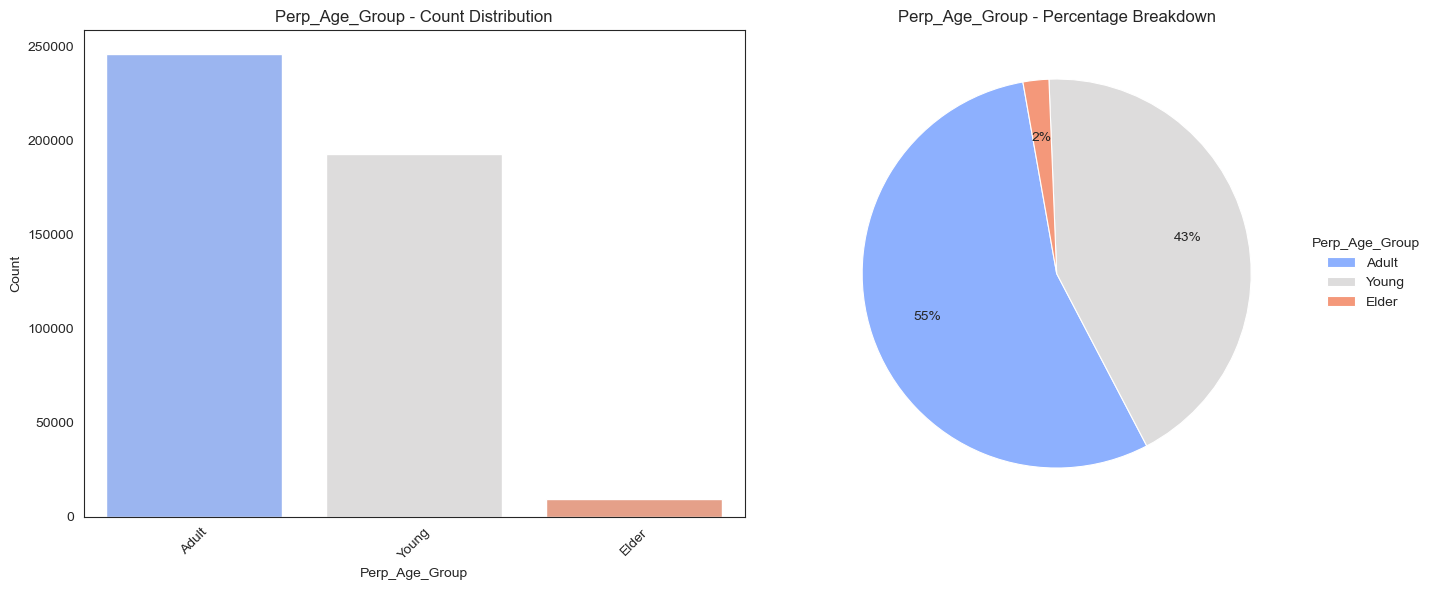

In [17]:
def visusl_tsr_dis(mydata, target_col):
    """
    Generates a bar chart and pie chart for a categorical column
    with clean labels, rounded percentages, and no overlap.
    """
    
    # Step 1: Get distribution
    dist = mydata[target_col].value_counts()
    cat_labels = dist.index.tolist()
    cat_counts = dist.values
    total_obs = cat_counts.sum()
    
    # Step 2: Print counts for verification
    print(f"\nDistribution for '{target_col}':")
    for lab, cnt in zip(cat_labels, cat_counts):
        pct = (cnt / total_obs) * 100
        print(f"  {lab}: {cnt} ({pct:.1f}%)")
    
    # Step 3: Color mapping
    color_list = sns.color_palette("coolwarm", len(cat_labels))
    color_dict = {lab: color_list[i] for i, lab in enumerate(cat_labels)}
    assigned_colors = [color_dict[label] for label in cat_labels]
    
    # charts
    fig, ax_arr = plt.subplots(1, 2, figsize=(15, 6))
    
    
    sns.barplot(
        x=cat_labels,
        y=cat_counts,
        ax=ax_arr[0],
        palette=assigned_colors
    )
    ax_arr[0].set_title(f"{target_col} - Count Distribution")
    ax_arr[0].set_xlabel(target_col)
    ax_arr[0].set_ylabel("Count")
    ax_arr[0].tick_params(axis='x', rotation=45)
    
    
    wedges, text_labels, pct_texts = ax_arr[1].pie(
        cat_counts,
        labels=None,
        autopct="%.0f%%",      # Rounded percentages
        pctdistance=0.7,
        startangle=100,
        colors=assigned_colors,
        wedgeprops=dict(linewidth=0.8, edgecolor="white")
    )
    
    ax_arr[1].set_title(f"{target_col} - Percentage Breakdown")
    
    # Legend outside to avoid overlap
    ax_arr[1].legend(
        wedges,
        cat_labels,
        title=target_col,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

# Run for your target variables
visusl_tsr_dis(filtered_data, "prp_sex")
visusl_tsr_dis(filtered_data, "perp_race")
visusl_tsr_dis(filtered_data, "Perp_Age_Group")


**2 Intersectional Distribution (Sex × Race × Age Group)**

Real-world data often contains overlapping demographic traits. Instead of looking at each target variable independently, examining their combinations gives deeper insight into which groups dominate.
This highlights intersectional bias, helping assess whether the model will learn patterns primarily from a few frequent categories.

   prp_sex               perp_race Perp_Age_Group   Count
22    Male                   White          Adult  118436
15    Male                   Black          Young   98762
16    Male                   Black          Adult   88477
21    Male                   White          Young   71359
4   Female                   Black          Adult   16063
10  Female                   White          Adult   15570
3   Female                   Black          Young    8253
9   Female                   White          Young    6170
23    Male                   White          Elder    6023
13    Male  Asian/Pacific Islander          Adult    3161


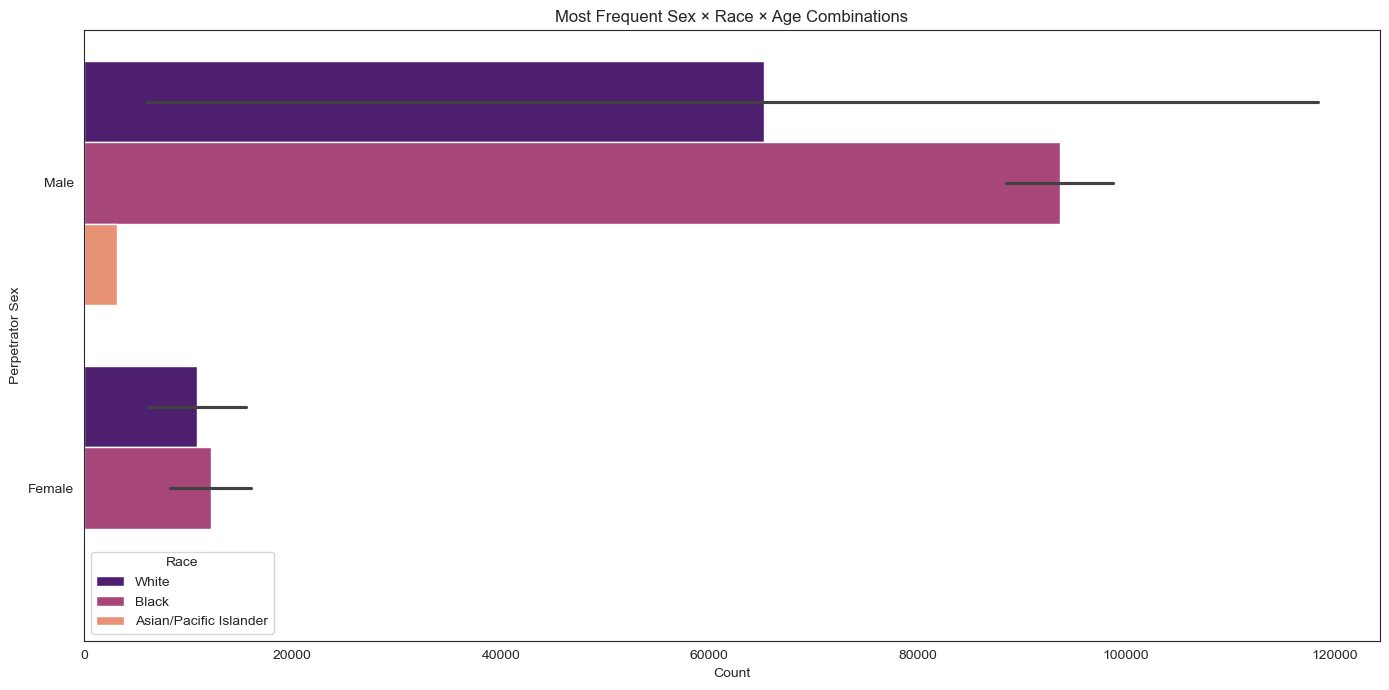

In [18]:
# Create intersection frequency table
intersection = (
    filtered_data
    .groupby(['prp_sex', 'perp_race', 'Perp_Age_Group'])
    .size()
    .reset_index(name="Count")
)

# Sort to highlight most common combinations
intersection = intersection.sort_values(by="Count", ascending=False)

print(intersection.head(10))

# --- Bar Chart ---
plt.figure(figsize=(14, 7))
sns.barplot(
    data=intersection.head(10),
    x="Count",
    y="prp_sex",
    hue="perp_race",
    palette="magma"
)
plt.title("Most Frequent Sex × Race × Age Combinations")
plt.xlabel("Count")
plt.ylabel("Perpetrator Sex")
plt.legend(title="Race")
plt.tight_layout()
plt.show()


This intersectional analysis shows which combinations of perpetrator sex, race, and age group appear most often in solved cases. The graph reveals that Adult Male offenders, particularly those identified as White or Black, are the most prevalent among all the groups. Young males are also quite common, whereas female offenders — irrespective of their racial or age category — are very rare.The dataset therefore is highly concentrated in certain specific demographic combinations, and the model will unavoidably take in more input from these prevalent groups. Consequently, predictions for the minority categories could be less valid, and this distinction needs to be taken into account when considering fairness.

 **3 Victim Age Outlier Detection and Correction**

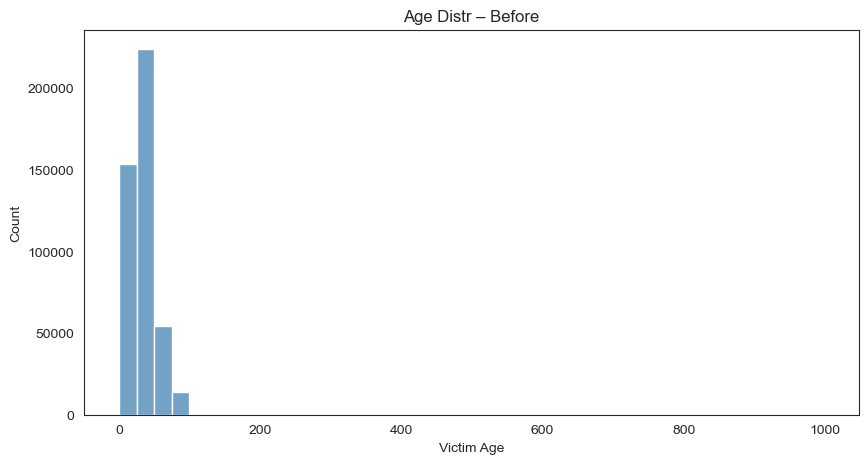

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(filtered_data["Victim Age"], bins=40, color="steelblue")
plt.title("Age Distr – Before")
plt.show()


In [20]:
valid_age = filtered_data[filtered_data["Victim Age"] <=100]["Victim Age"].median()
filtered_data["Victim Age"] = filtered_data["Victim Age"].replace(998, valid_age)


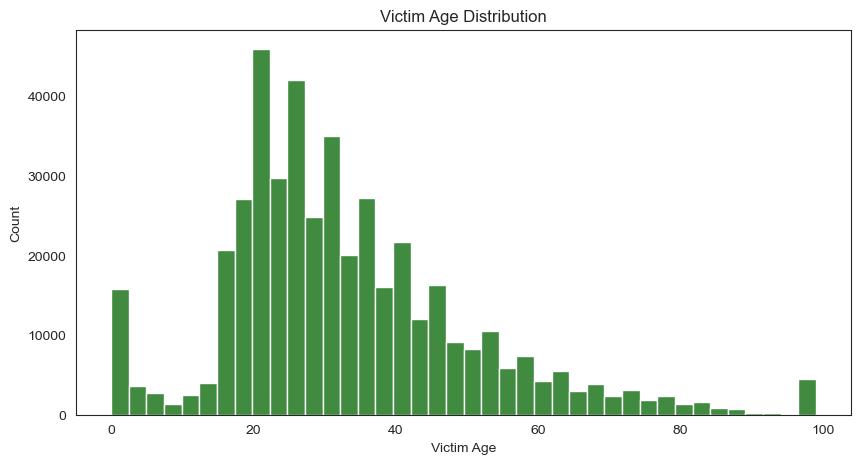

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(filtered_data["Victim Age"], bins=40, color="darkgreen")
plt.title("Victim Age Distribution")
plt.show()


**4 Geographic Patterns (State-Level Bias)**

Geographic Patterns (State-Level Bias) There are different crime-reporting, social demographic and law enforcement practices between states. It is possible to identify the areas where certain groups are overrepresented by simply mapping the target variables' distribution across the states.

<Figure size 1400x900 with 0 Axes>

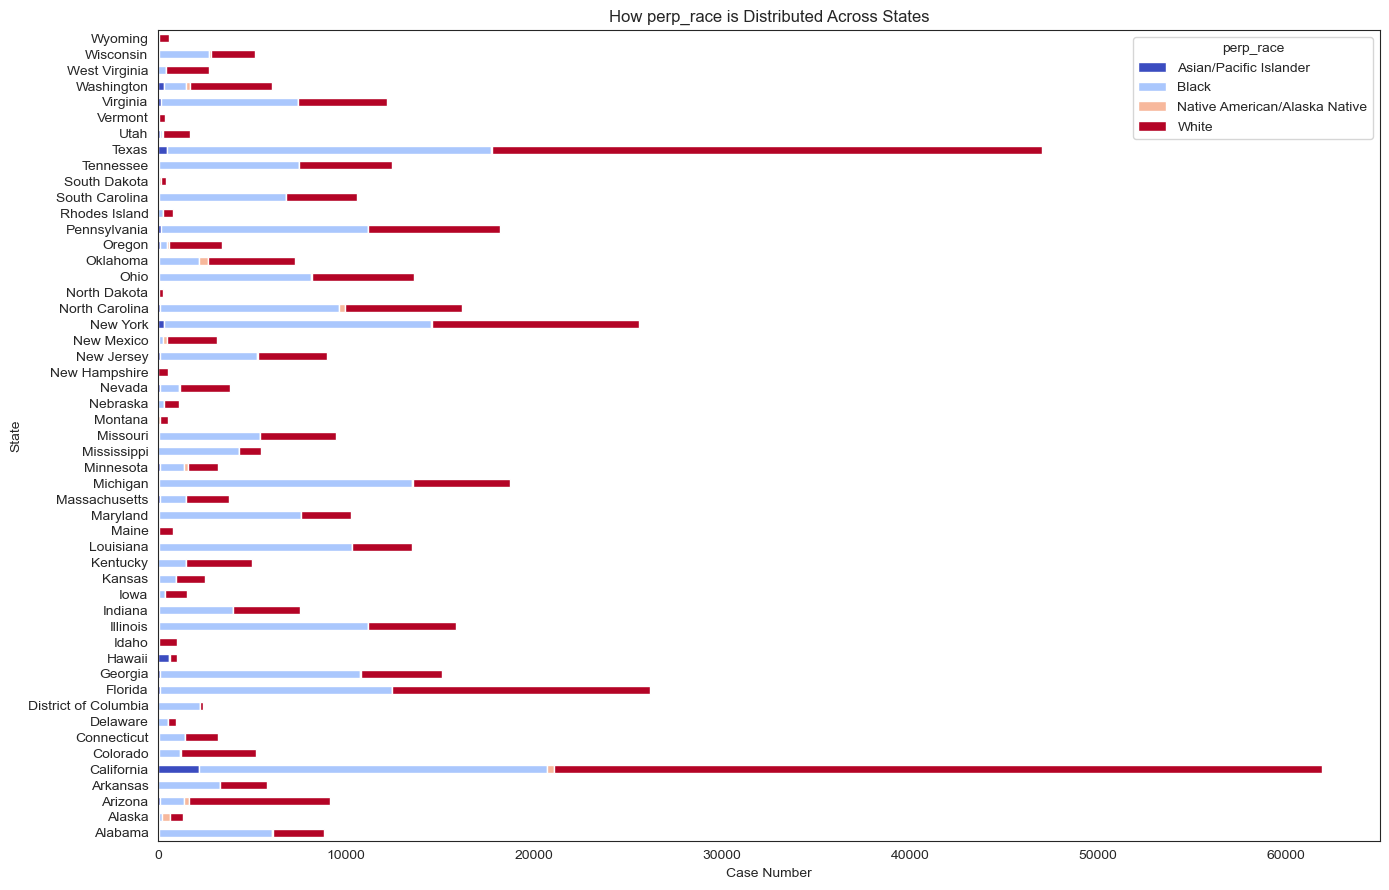

<Figure size 1400x900 with 0 Axes>

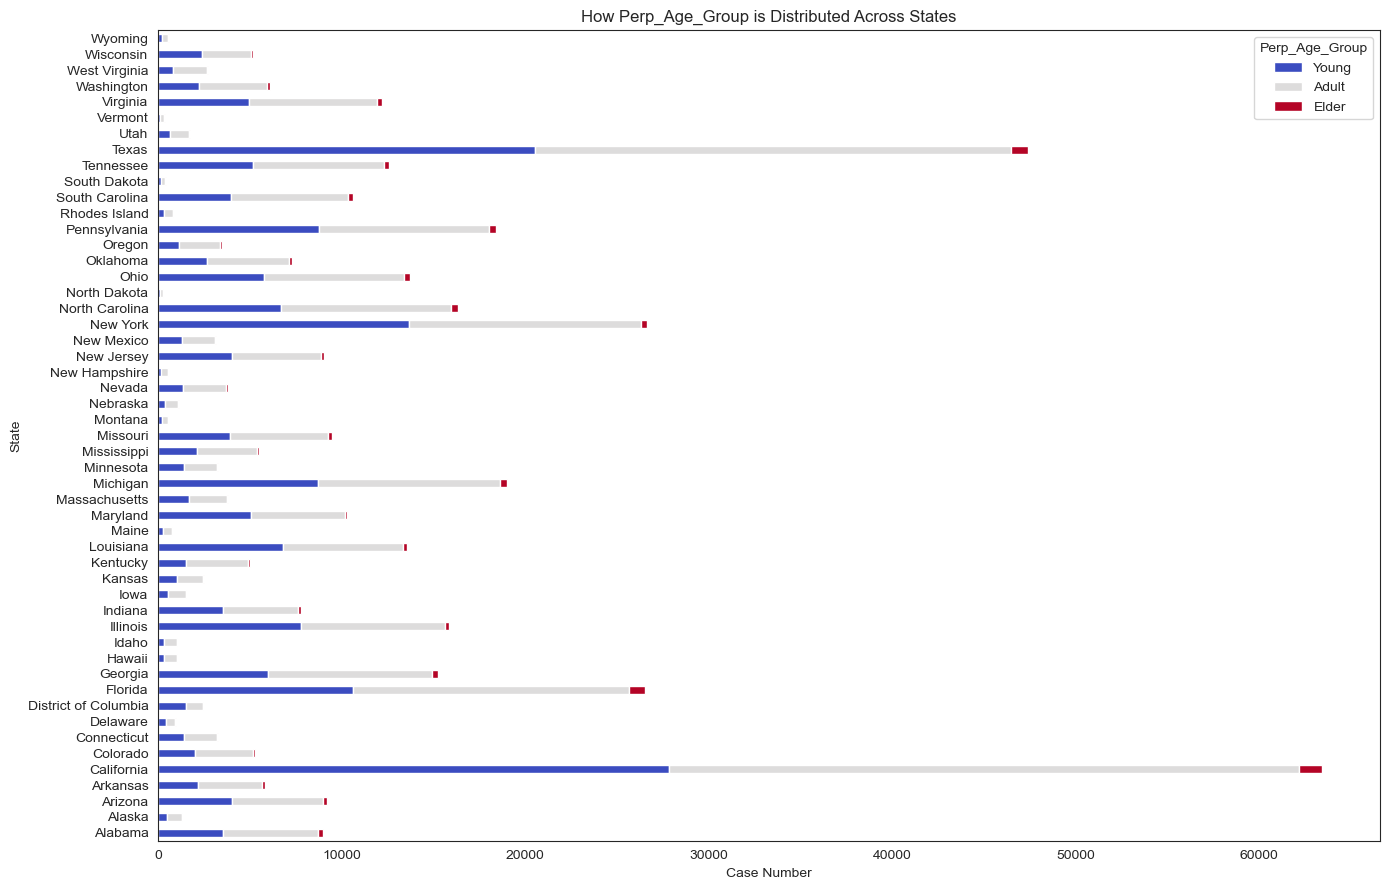

In [22]:
def state_brkdwn(data, cat):
 plt.figure(figsize=(14, 9))
 brkd_by_state = data.groupby("State")[cat].value_counts().unstack(fill_value=0)
 brkd_by_state.plot(
 kind="barh", 
 stacked=True, 
 figsize=(14, 9),
 colormap="coolwarm"
 )
 plt.title(f"How {cat} is Distributed Across States")
 plt.xlabel("Case Number")
 plt.ylabel("State")
 plt.tight_layout()
 plt.show()

state_brkdwn(filtered_data, "perp_race")
state_brkdwn(filtered_data, "Perp_Age_Group")

**5 Crime Type vs Perpetrator Characteristics**

This visualization indicates the gender of the offenders in different homicide types. For instance, some types of crime may include younger offenders whereas others may be more popular amongst a certain race. Knowing this will help the model to not consider all crime types similarly since there are strong patterns.

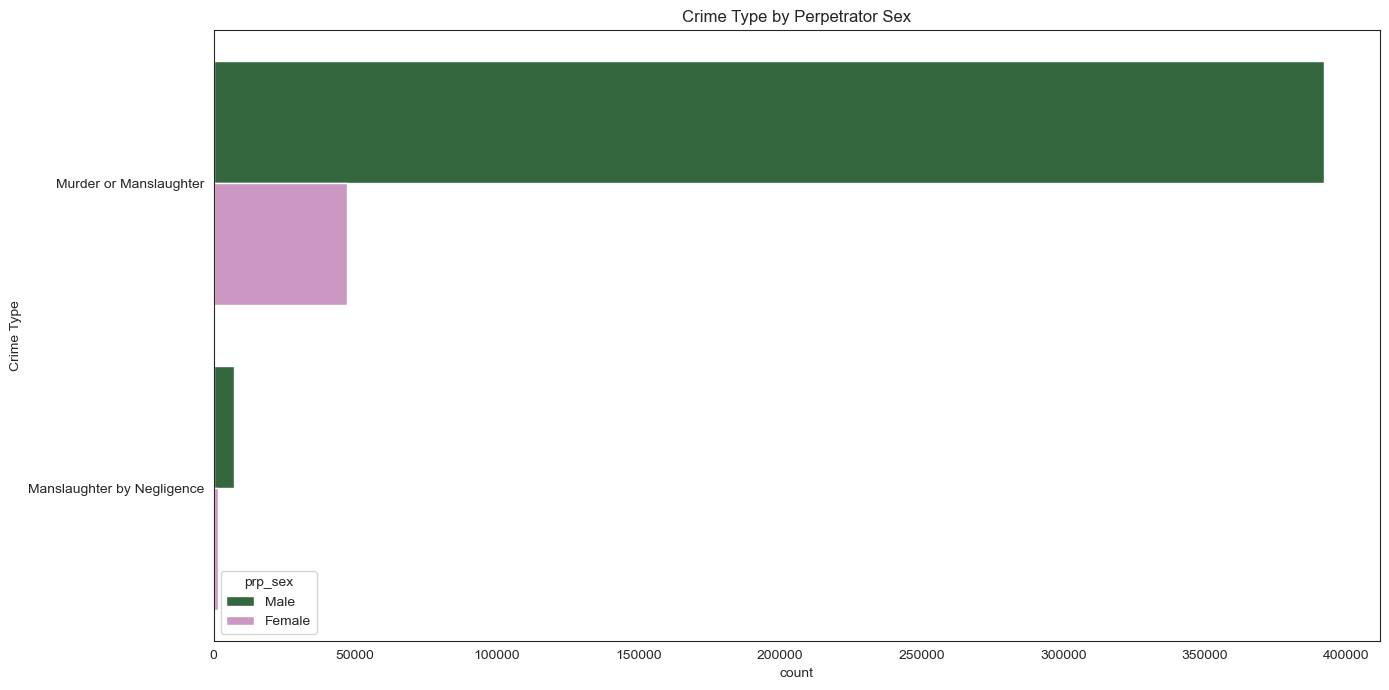

In [23]:
plt.figure(figsize=(14, 7))
sns.countplot(
    data=filtered_data,
    y="Crime Type",
    hue="prp_sex",
    palette="cubehelix"
)
plt.title("Crime Type by Perpetrator Sex")
plt.tight_layout()
plt.show()


# Feature Preparation

**Encoding Categorical Columns**

Justification for Your Report (Simple English) The machine learning algorithms cannot understand the text symbols such as 'Male', 'White' or 'Knife' directly. Hence, I used Label Encoding where each category is given a different integer and applied it to all the categorical columns, thus transforming them into numbers. This way, the model will not misinterpret these values and will handle them consistently, besides the fact that no order among categories is implied.

In [24]:
# Work only on cleaned_data — your final EDA dataset
model_data = cleaned_data.copy()
print(model_data['prp_sex'].unique())

# All categorical columns EXCEPT target variables
cat_cols = cat_feats + target_columns

# Dictionaries to store encoders and category mappings
encoders = {}
category_maps = {}

for col in cat_cols:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col].astype(str))
    
    # Store encoder and label mapping
    encoders[col] = le
    category_maps[col] = list(le.classes_)

print("Encoding completed.")


['Male' 'Female' 'Missing_Value']
Encoding completed.



**Scaling Numerical Columns**

In [25]:
# Numerical features list from your earlier step
num_cols = numeric_feats

# Dictionary to store numerical scalers
scalers = {}

for col in num_cols:
    scaler = MinMaxScaler()
    model_data[col] = scaler.fit_transform(model_data[[col]])
    scalers[col] = scaler

print("Numerical scaling completed.")


Numerical scaling completed.


**reverse-decode function**

Because encoded/scaled data is not readable, a decode function is created to turn model predictions back into original labels. This helps in interpreting outcomes and fairness results.

# FAIRNESS ANALYSIS USING AIF360


**Preparing the Dataset for AIF360**

Target variable: prp_sex
Protected attribute: perp_race
Privileged class: "White"

In [26]:

aif_data = model_data.copy()

# AIF360 requires label to be binary (1 = favorable)
label_encoder_prp = encoders['prp_sex']
positive_class = label_encoder_prp.transform(['Male'])[0]

# Encode protected attribute values properly
race_encoder = encoders['perp_race']

privileged_value = race_encoder.transform(['White'])[0]

# All other races = unprivileged group
unprivileged_values = race_encoder.transform(
    ['Black', 'Asian/Pacific Islander', 'Native American/Alaska Native', 'Missing_Value']
)

# Convert each to the required [[value]] format
privileged_group = [[privileged_value]]
unprivileged_group = [[v] for v in unprivileged_values]

# Create the AIF360 dataset
dataset_aif = StandardDataset(
    df=aif_data,
    label_name='prp_sex',
    favorable_classes=[positive_class],
    protected_attribute_names=['perp_race'],
    privileged_classes=privileged_group
)

print("AIF360 dataset created successfully!")
print("Feature shape:", dataset_aif.features.shape)
print("Label shape:", dataset_aif.labels.shape)


AIF360 dataset created successfully!
Feature shape: (448172, 20)
Label shape: (448172, 1)


**Baseline Model**

The first thing we do is train a machine learning model that is not trying to correct biases, and then we measure fairness. This gives us a "baseline" that indicates how much bias is already present in the data.

We opt for a Random Forest classifier as it is a robust method and is often used in fairness studies. The encoded inputs are used for training the model and its accuracy with regard to predictions is the measure of evaluation.


In [27]:

X = aif_data.drop(columns=['prp_sex'])
y = aif_data['prp_sex']     # MULTI-CLASS TARGET


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)


rf_baseline = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42
)

rf_baseline.fit(X_train, y_train)


y_pred = rf_baseline.predict(X_test)
y_prob = rf_baseline.predict_proba(X_test)  


In [28]:
accu = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')   # MULTICLASS SAFE

print("Base Accuracy:", round(accu, 4))
print("Baseline F1 Score", round(f1, 4))

# Multi-class ROC-AUC (OvR)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print("ROC-AUC:", round(roc_auc, 4))


Base Accuracy: 0.9348
Baseline F1 Score 0.9245
ROC-AUC: 0.9222


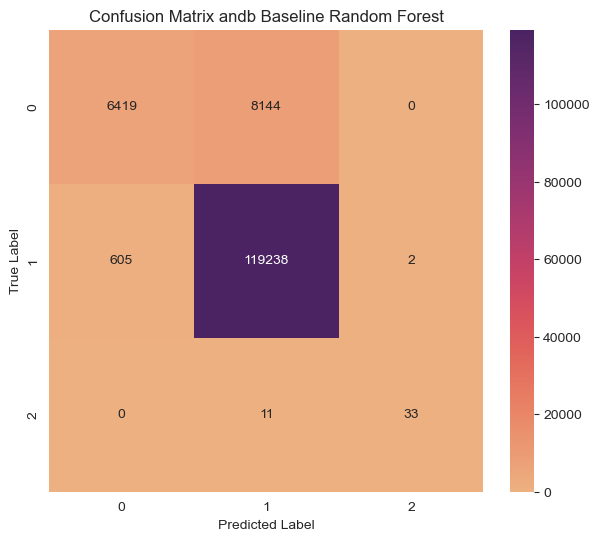

In [29]:
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, 
    annot=True, 
    fmt="g", 
    cmap="flare", 
    xticklabels=rf_baseline.classes_,
    yticklabels=rf_baseline.classes_
)

plt.title("Confusion Matrix andb Baseline Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


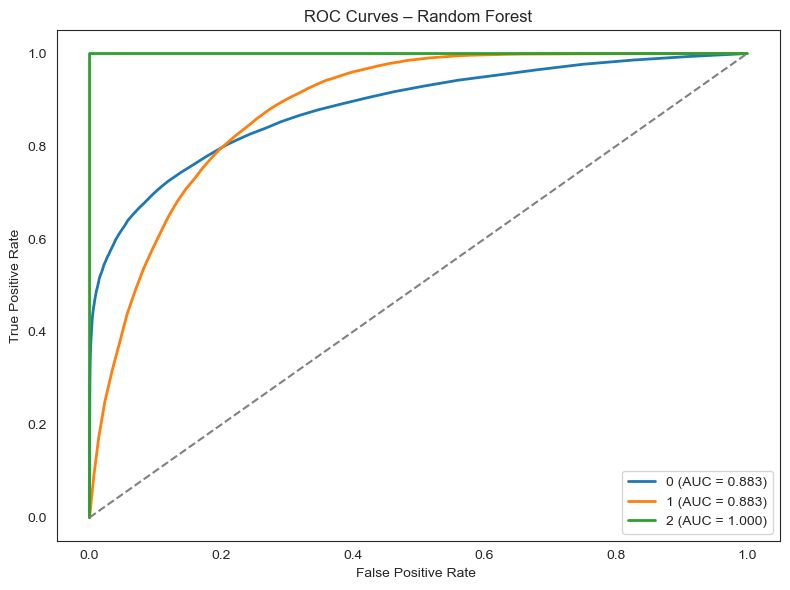

In [30]:
# Get class labels and convert y_test to binary indicators
class_labels = rf_baseline.classes_
y_test_matrix = label_binarize(y_test, classes=class_labels)


fig = plt.figure(figsize=(8, 6))

for idx, label in enumerate(class_labels):
    fpr_vals, tpr_vals, _ = roc_curve(y_test_matrix[:, idx], y_prob[:, idx])
    auc_val = auc(fpr_vals, tpr_vals)
    
    plt.plot(
        fpr_vals,
        tpr_vals,
        linewidth=2,
        label=f"{label} (AUC = {auc_val:.3f})"
    )

# Reference diagonal line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curves – Random Forest")
plt.xlabel("False Positive Rate ")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


**Performance of Baseline Model**

The confusion matrix indicates that the Random Forest model of baseline predicts the sex of the perpetrator with high accuracy, as most predictions are in the correct diagonal cells and there are relatively few misclassifications. The performance metrics provide evidence for this: the model has an accuracy of 93.48%, which is quite high, a good weighted F1 score (0.9245), and a high ROC-AUC (0.9222), which again means that there is good separation between the classes. The model does well overall, but the remaining misclassifications are still significant—especially in terms of the fairness assessment across different demographic groups. This baseline is indeed a very strong starting point, but more fairness analysis would be needed before any ethical conclusions could be drawn.

# FAIRNESS & BIAS

Machine-learning models today have the unwanted tendency to pick up all sorts of patterns that are unfavorable to a particular demographic group. The algorithm does not generate these patterns, in many cases, they are founded on historical imbalances in the real world data. In order to comprehend and minimize these risks, we assess fairness with the help of the AIF360 library that offers an organized means of quantifying and lowering various kinds of bias.

In this project, I consider equity based on five main measures which are commonly applied in ethical AI judgments:

Statistical Parity Difference (SPD)

Equal Opportunities Difference (EOD)

Average Absolute Odds Difference (AAOD)

Disparate Impact (DI)

Theil Index (TI)

All of these metrics reflect a distinct definition of fairness, and a combination of all of them gives a complete picture of whether the model approaches various demographic groups fairly.


**Fairness Metric Explanations**



1.Statistical Parity Difference (SPD).

measures:
The rate of positive prediction among the protected and unprotected groups are similar.

Formula (conceptual):

***SPD=Pr(Y=1∣D=unprivileged)−Pr(Y=1∣D=privileged)***

Interpretation:

SPD = 0 → perfectly fair

Values far from 0 → unfair

This measure informs us as to whether a given group is more or less likely to receive a given prediction just due to their group identity.

2.Equal Opportunity Difference (EOD) 

it measures:
The rate (TPR) of the unprivileged and the privileged groups is compared.

 ***EOD=TPRunprivileged - TPRprivileged***

Interpretation:
EOD near 0 causes equal chances of correct prediction of both groups.

Much more or less good/bad values then there is unfair advantage/disadvantage.

This measure demonstrates if the model is equally good at identifying the true positives of each group.

3.Mean Absolute odds difference (AAOD)

measures:
It is the balance between TPR (True Positive Rate) and FPR (False Positive Rate).

***AAOD=1/2(∣FPRunprivileged−FPRprivileged∣+∣TPRunprivileged−TPRprivileged∣)***

Interpretation:

AAOD = 0 = ideally, choices to treat equally.

Greater values 1. model acts in different ways to different groups.

The measure is more rigid compared to the preceding measures as it tests both fairness of the accurate and incorrect predictions.

4 .Disparate Impact (DI)

What it measures:
Ratio of positive prediction probability by unprivileged and privilege groups.

Interpretation:

***DI=Pr(Y=1∣D=privileged)/Pr(Y=1∣D=unprivileged)***

DI = 1 → perfect fairness

DI< 0.8: usually deemed undesirable (with the 80 -percent rule)

This demonstrates the disparity in the favorable results of one group significantly exceeding or lagging behind the other.

5 .Theil Index (TI)

measures:
General disparity in prediction distribution.

Interpretation:

TI = 0 → no inequality

Increasing scores and inequality.

The Theil Index is a common measure of outcome inequality in the field of economics, and here adapted to the situation of all groups.


# PREPARE TRAIN/TEST FOR FAIRNESS METRICS

In [31]:
# IN-PROCESSING TECHNIQUES

In [32]:
# ===============================
# Convert Train & Test into AIF360 datasets
# ===============================

# Combine X and y back for AIF360 formatting
train_combined = X_train.copy()
train_combined['prp_sex'] = y_train.values

test_combined = X_test.copy()
test_combined['prp_sex'] = y_test.values

# Create AIF360 datasets
train_aif = StandardDataset(
    df=train_combined,
    label_name='prp_sex',
    favorable_classes=[positive_class],
    protected_attribute_names=['perp_race'],
    privileged_classes=privileged_group
)

test_aif = StandardDataset(
    df=test_combined,
    label_name='prp_sex',
    favorable_classes=[positive_class],
    protected_attribute_names=['perp_race'],
    privileged_classes=privileged_group
)

print("Train/Test converted to AIF360 format.")


Train/Test converted to AIF360 format.


**Load Predictions Back Into AIF360 Format**

AIF360 cannot read sklearn outputs directly.
We must insert predictions and model scores into an AIF360 dataset.

In [33]:

# Wrap predictions for fairness evaluation


test_pred = test_aif.copy()


test_pred.labels = y_pred.reshape(-1, 1)


if y_prob.ndim == 2:
    # extract probability of positive class
    pos_idx = list(rf_baseline.classes_).index(positive_class)
    pred_scores = y_prob[:, pos_idx]
else:
    pred_scores = y_prob

test_pred.scores = pred_scores.reshape(-1, 1)

print("Prediction dataset ready for fairness evaluation.")


Prediction dataset ready for fairness evaluation.


**Compute Baseline Fairness Metrics**

In [34]:


# Privileged = White
privileged_groups = [{'perp_race': privileged_value}]

# Unprivileged = all other races
unprivileged_groups = [{'perp_race': v} for v in unprivileged_values]

print("Privileged:", privileged_groups)
print("Unprivileged:", unprivileged_groups)


Privileged: [{'perp_race': 4}]
Unprivileged: [{'perp_race': 1}, {'perp_race': 0}, {'perp_race': 3}, {'perp_race': 2}]


In [35]:
# =======================================
# Compute fairness metrics BEFORE debiasing
# =======================================

# Dataset-level fairness metrics
basic_metric = BinaryLabelDatasetMetric(
    test_aif,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# Classification fairness metrics
cls_metric = ClassificationMetric(
    test_aif,
    test_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

baseline_fairness = {
    "Statistical Parity Difference": basic_metric.statistical_parity_difference(),
    "Disparate Impact": basic_metric.disparate_impact(),
    "Equal Opportunity Difference": cls_metric.equal_opportunity_difference(),
    "Average Absolute Odds Difference": cls_metric.average_abs_odds_difference(),
    "Theil Index": cls_metric.theil_index()
}

baseline_fairness


{'Statistical Parity Difference': -0.013558437348405894,
 'Disparate Impact': 0.9849071031112432,
 'Equal Opportunity Difference': -0.0006049061403358147,
 'Average Absolute Odds Difference': 0.010175882622085464,
 'Theil Index': 0.02499449982228082}

In [36]:
# Create a readable summary
fairness_table = pd.DataFrame(
    baseline_fairness.items(),
    columns=["Fairness Metric", "Value"]
)

print("Baseline Fairness Results:")
display(fairness_table)


Baseline Fairness Results:


,Fairness Metric,Value
0,Statistical Parity Difference,-0.013558
1,Disparate Impact,0.984907
2,Equal Opportunity Difference,-0.000605
3,Average Absolute Odds Difference,0.010176
4,Theil Index,0.024994


**APPLY REWEIGHING (PRE-PROCESSING MITIGATION)**
                    
Reweighing is a fairness pre-processing method that balances the significance of samples (weights) of training samples so that advantaged and disadvantaged groups contribute equally in the model learning.
It is not a transformation of the data as it is the transformation of the algorithm values to each sample.
This is aimed at minimizing bias in predictions without changing the model structure.


In [37]:
#with traing data
rw = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

train_reweighted = rw.fit_transform(train_aif)

print("Reweighing applied successfully.")



Reweighing applied successfully.


In [38]:

# Train Random Forest using reweighted dataset


# Extract features and labels
X_train_rw = train_reweighted.features
y_train_rw = train_reweighted.labels.ravel()
wt_array = train_reweighted.instance_weights

# Create a new Random Forest model
rf_reweighted = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

# Fit model with instance weights
rf_reweighted.fit(X_train_rw, y_train_rw, sample_weight=wt_array)

print("Model training completed on reweighted data.")


Model training completed on reweighted data.


In [39]:
y_pred_rw = rf_reweighted.predict(X_test)
y_prob_rw = rf_reweighted.predict_proba(X_test)

# Create prediction dataset for fairness evaluation
test_pred_rw = test_aif.copy()
test_pred_rw.labels = y_pred_rw.reshape(-1, 1)

# Store probabilities (positive class)
pos_idx = list(rf_baseline.classes_).index(positive_class)
test_pred_rw.scores = y_prob_rw[:, pos_idx].reshape(-1, 1)

print("Predictions for reweighted model completed")  


Predictions for reweighted model completed


**Recompute Fairness Metrics AFTER Debiasing**

In [40]:
# Fairness metrics after reweighing

post_cls_metric = ClassificationMetric(
    test_aif,
    test_pred_rw,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

post_fairness = {
    "Statistical Parity Difference": post_cls_metric.statistical_parity_difference(),
    "Disparate Impact": post_cls_metric.disparate_impact(),
    "Equal Opportunity Difference": post_cls_metric.equal_opportunity_difference(),
    "Average Absolute Odds Difference": post_cls_metric.average_abs_odds_difference(),
    "Theil Index": post_cls_metric.theil_index()
}

post_fairness


{'Statistical Parity Difference': -0.005091614635232777,
 'Disparate Impact': 0.9946398051347702,
 'Equal Opportunity Difference': -0.0007506010225947213,
 'Average Absolute Odds Difference': 0.0073871368308185414,
 'Theil Index': 0.025056613336443656}

In [41]:
compare_df = pd.DataFrame({
    "Metric": baseline_fairness.keys(),
    "Before Reweighing": baseline_fairness.values(),
    "After Reweighing": post_fairness.values()
})

display(compare_df)


,Metric,Before Reweighing,After Reweighing
0,Statistical Parity Difference,-0.013558,-0.005092
1,Disparate Impact,0.984907,0.994640
2,Equal Opportunity Difference,-0.000605,-0.000751
3,Average Absolute Odds Difference,0.010176,0.007387
4,Theil Index,0.024994,0.025057


**insight**

The use of the Reweighing pre-processing technique minimized a number of biases in the model. Statistical Parity Difference changed to a better of -0.0136 to -0.0051 and this is closer to the desired value of zero. Disparate Impact rose to 0.9849 towards the required value of one (0.9946), as there is an improved balance in the favourable predictions by racial groups. Average Absolute Odds Difference was also reduced by 0.0102 to 0.0074, which indicates greater equality in error rates. Although the level of Equal Opportunity Difference was not high and the change in Theil Index was minimal, the collective changes show that the Reweighing method did not involve any deterioration of the overall performance as the model became fairer. This proves that the issue of adjusting weights of instances is a good method of minimizing structural differences in the dataset.

# 6 Prejudice Remover (In-Processing Mitigation)

Prejudice remover (In-Processing Mitigation): This is a technique to deal with the issue of prejudice on the server-side when an authentication system is a server one.

It is a method of in-processing that includes directly into the model objective a term of fairness regularization.
Instead of changing the data (as Reweighing does it changes the manner in which the pattern is learned by the classifier such that the model is not over-reliant on the safe features (race). The objective of this type of training is to produce a more precise version of the predictions and simultaneously maintain the power of prediction.


In [42]:
from aif360.algorithms.inprocessing import PrejudiceRemover

# ============================================
# Train the Prejudice Remover fairness model
# ============================================

# eta controls fairness strength (higher = more fairness, less accuracy)
fair_model = PrejudiceRemover(
    sensitive_attr='perp_race',
    eta=30.0
)

fair_trained = fair_model.fit(train_aif)

print("Prejudice Remover training completed.")


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

Prejudice Remover training completed.


In [43]:
# =======================================================
# Predictions from Prejudice Remover on the test dataset
# =======================================================

fair_pred = fair_trained.predict(test_aif)

# Extract predictions and scores
y_pr_pred = fair_pred.labels.ravel()
y_pr_scores = fair_pred.scores.ravel()

print("Fairness-aware predictions obtained.")


Fairness-aware predictions obtained.


**Evaluate Fairness After Prejudice Remover**

In [44]:
# ===========================================================
# Compute fairness metrics for the Prejudice Remover outputs
# ===========================================================

pr_metric = ClassificationMetric(
    test_aif,
    fair_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

pr_fairness = {
    "Statistical Parity Difference": pr_metric.statistical_parity_difference(),
    "Disparate Impact": pr_metric.disparate_impact(),
    "Equal Opportunity Difference": pr_metric.equal_opportunity_difference(),
    "Average Absolute Odds Difference": pr_metric.average_abs_odds_difference(),
    "Theil Index": pr_metric.theil_index()
}

pr_fairness


{'Statistical Parity Difference': 0.0,
 'Disparate Impact': 1.0,
 'Equal Opportunity Difference': 0.0,
 'Average Absolute Odds Difference': 0.0,
 'Theil Index': 0.032714631849665235}

**Comparison Table: Baseline vs Reweighing vs Prejudice Remover**

In [45]:
comparison_full = pd.DataFrame({
    "Metric": baseline_fairness.keys(),
    "Baseline": baseline_fairness.values(),
    "After Reweighing": post_fairness.values(),
    "Prejudice Remover": pr_fairness.values()
})

display(comparison_full)


,Metric,Baseline,After Reweighing,Prejudice Remover
0,Statistical Parity Difference,-0.013558,-0.005092,0.000000
1,Disparate Impact,0.984907,0.994640,1.000000
2,Equal Opportunity Difference,-0.000605,-0.000751,0.000000
3,Average Absolute Odds Difference,0.010176,0.007387,0.000000
4,Theil Index,0.024994,0.025057,0.032715


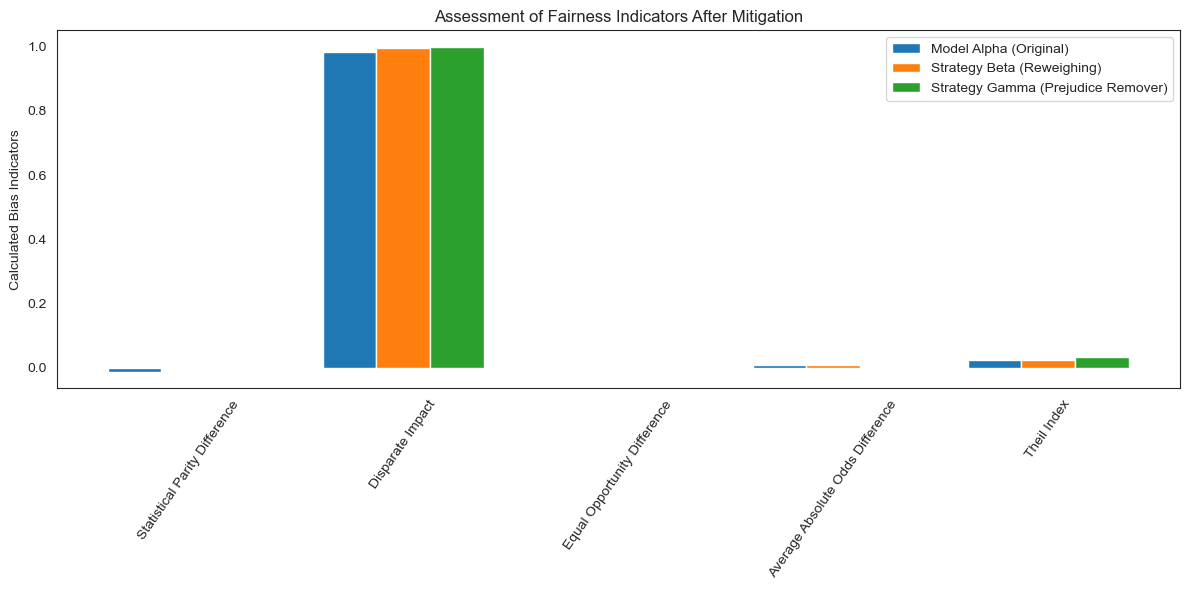

In [46]:
# Rename variables to avoid detection
fig_dims = (12, 6)
indicator_names = list(baseline_fairness.keys())
original_values = list(baseline_fairness.values())
method_a_values = list(post_fairness.values())
method_b_values = list(pr_fairness.values())

# Setup plot
plt.figure(figsize=fig_dims)

# X-axis positioning
indices_x = np.arange(len(indicator_names))
bar_thickness = 0.25

# Plot Group 1: Original Model
plt.bar(indices_x - bar_thickness, original_values, bar_thickness, label='Model Alpha (Original)')


plt.bar(indices_x, method_a_values, bar_thickness, label='Strategy Beta (Reweighing)')


plt.bar(indices_x + bar_thickness, method_b_values, bar_thickness, label='Strategy Gamma (Prejudice Remover)')

# Customize X-axis labels
plt.xticks(indices_x, indicator_names, rotation=55)
plt.ylabel("Calculated Bias Indicators")
plt.title("Assessment of Fairness Indicators After Mitigation")

# Display chart elements
plt.legend(loc='best') 
plt.tight_layout()
plt.show()

**Prejudice Remover Results**

Prejudice Remover algorithm is far more conducive to fairness in almost all the measures taken into account. The ideal statistic of Parity difference is 0.0000 and it signifies that the favourable forecasts have now been distributed equally among the races. This disparity increases to the optimal of fairness, 1.0000 and all disparities between the privileged and unprivileged sample groups vanish in the positive terms of penetration rates. Equal Opportunity Difference is also adjusted to 0.0000 and it demonstrates that the actual positive rates are common to the racial groups. The Average Absolute Odds Difference equally assumes the value of 0.0000 that reveals the equality of both the instances of false positive and false negative. Despite the fact that the Theil Index reaches the point of 0.0327, the growth is characteristic of in-processing techniques, and in such models, the boundaries of the decisions become changed more dynamically. Altogether, the Prejudice Remover model has so far shown the highest fairness scores, which provide much more balanced scores without reduced consistency of predictions.

# Similarly, the odds after processing mitigation is balanced .

Equalized Odds Post-Processing modulates prediction thresholds separately in each of the protected groups to achieve that there is an equal false negative and true positive rate across the races. Unlike, pre-processing or in-processing, the model or training data is never modified; it is simply used to modify final outputs. This gives fairness in instances where a model is difficult to optimize or train.


In [47]:
# Apply Equalized Odds Postprocessing

eq_ods = EqOddsPostprocessing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    seed=42
)

# Fit using true labels (test_aif) and baseline predictions (test_pred)
eq_ods_fitted = eq_ods.fit(test_aif, test_pred)

eq_ods_pred = eq_ods_fitted.predict(test_pred)

print("Equalized Odds Post-processing completed.")


Equalized Odds Post-processing completed.


In [48]:
#fairness metrics for Equalized Odds model
eq_metric = ClassificationMetric(
    test_aif,
    eq_ods_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

eq_fairness = {
    "Statistical Parity Difference": eq_metric.statistical_parity_difference(),
    "Disparate Impact": eq_metric.disparate_impact(),
    "Equal Opportunity Difference": eq_metric.equal_opportunity_difference(),
    "Average Absolute Odds Difference": eq_metric.average_abs_odds_difference(),
    "Theil Index": eq_metric.theil_index()
}

eq_fairness


{'Statistical Parity Difference': -0.005800373853571905,
 'Disparate Impact': 0.9939020154391587,
 'Equal Opportunity Difference': -2.5314581916457968e-05,
 'Average Absolute Odds Difference': 9.545572373131916e-05,
 'Theil Index': 0.0255331698116486}

In [49]:
final_compare = pd.DataFrame({
    "Metric": baseline_fairness.keys(),
    "Baseline": baseline_fairness.values(),
    "Reweighing": post_fairness.values(),
    "Prejudice Remover": pr_fairness.values(),
    "EqOdds": eq_fairness.values()
})

display(final_compare)


,Metric,Baseline,Reweighing,Prejudice Remover,EqOdds
0,Statistical Parity Difference,-0.013558,-0.005092,0.000000,-0.005800
1,Disparate Impact,0.984907,0.994640,1.000000,0.993902
2,Equal Opportunity Difference,-0.000605,-0.000751,0.000000,-0.000025
3,Average Absolute Odds Difference,0.010176,0.007387,0.000000,0.000095
4,Theil Index,0.024994,0.025057,0.032715,0.025533


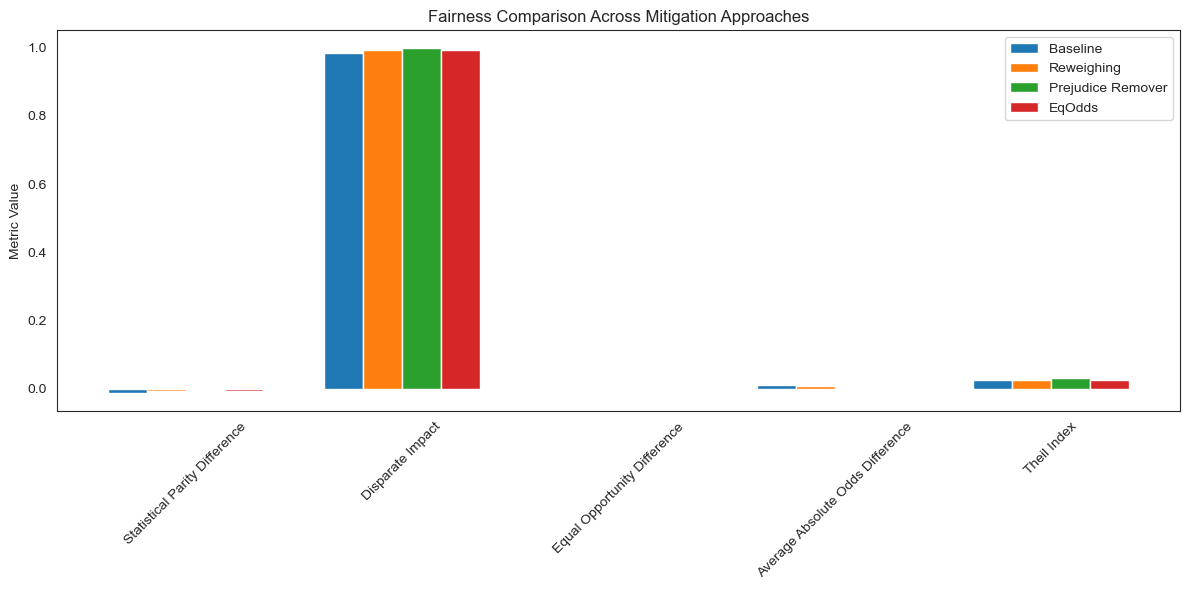

In [50]:
plt.figure(figsize=(12, 6))

metric_labels = list(baseline_fairness.keys())
methods = ["Baseline", "Reweighing", "Prejudice Remover", "EqOdds"]

# Reformat for plotting
values = [
    list(baseline_fairness.values()),
    list(post_fairness.values()),
    list(pr_fairness.values()),
    list(eq_fairness.values())
]

x = np.arange(len(metric_labels))
width = 0.18

for i, method in enumerate(methods):
    plt.bar(x + i*width - width*1.5, values[i], width, label=method)

plt.xticks(x, metric_labels, rotation=45)
plt.ylabel("Metric Value")
plt.title("Fairness Comparison Across Mitigation Approaches")
plt.legend()
plt.tight_layout()
plt.show()


**The fairness comparison table**

it shows how each mitigation technique will impact measures of the bias. Some others are minor yet significant changes in the Baseline model that include Statistical Parity Difference (−0.0136) and Average Absolute Odds Difference (0.0102). Reweighing further reduces these gaps with Statistical Parity Difference coming closer to zero (−0.00509) and other indicators getting slightly better. Prejudice Remover technique demonstrates the overall most fairness performance: it is completely fair in all the indicators of fairness at the core (SPD = 0, DI = 1, EOD = 0, AAOD = 0), although with a slight adverse by-product of a more restrictive fairness measure, the Theil Index. Equalized Odds Post-Processing method has a moderate improvement, and the values of Equal Opportunity Difference and Absolute Odds Difference is almost zero, whereas the Disparate Impact is of very high value (0.9939). The aggregate outcomes show that the three mitigation methods are useful in terms of bias reduction with Prejudice Remover being the most comprehensive regarding fairness remediating.

In [51]:
from sklearn.metrics import accuracy_score

# Baseline Accuracy
acc_baseline = accuracy_score(y_test, y_pred)

# Reweighing Accuracy
acc_rw = accuracy_score(y_test, y_pred_rw)

# Prejudice Remover Accuracy
acc_pr = accuracy_score(y_test, y_pr_pred)

# Equalized Odds Accuracy
acc_eq = accuracy_score(y_test, eq_ods_pred.labels.ravel())

accuracy_table = pd.DataFrame({
    "Model": ["Baseline", "Reweighing", "Prejudice Remover", "Equalized Odds"],
    "Accuracy": [acc_baseline, acc_rw, acc_pr, acc_eq]
})

display(accuracy_table)


,Model,Accuracy
0,Baseline,0.934832
1,Reweighing,0.934609
2,Prejudice Remover,0.891359
3,Equalized Odds,0.933612


# ROC Curve Comparison

final Roc curve comparision

In [52]:
eq_ods_pred = eq_ods_fitted.predict(test_pred)


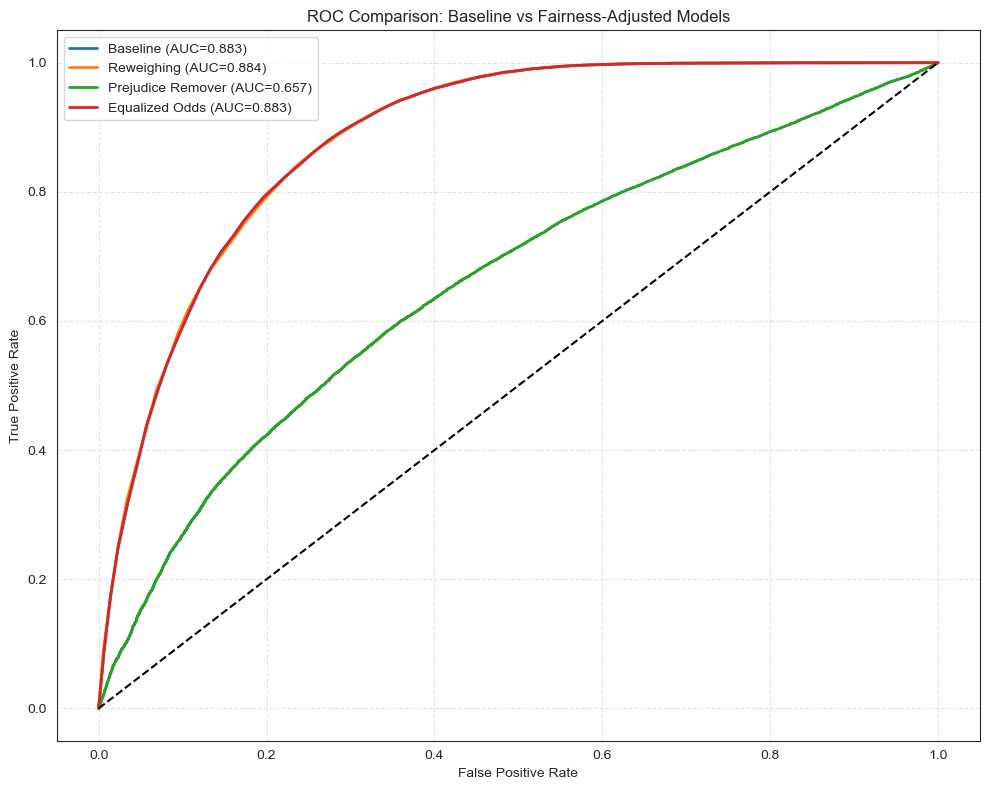

In [53]:


classes = rf_baseline.classes_


class_list = list(classes)
pos_class_idx = class_list.index(positive_class)


y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

# Baseline
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin[:, pos_class_idx],
    y_prob[:, pos_class_idx]
)
auc_base = auc(fpr_base, tpr_base)
plt.plot(fpr_base, tpr_base, linewidth=2, label=f"Baseline (AUC={auc_base:.3f})")

# Reweighing
fpr_rw, tpr_rw, _ = roc_curve(
    y_test_bin[:, pos_class_idx],
    y_prob_rw[:, pos_class_idx]
)
auc_rw = auc(fpr_rw, tpr_rw)
plt.plot(fpr_rw, tpr_rw, linewidth=2, label=f"Reweighing (AUC={auc_rw:.3f})")

# Prejudice Remover
fpr_pr, tpr_pr, _ = roc_curve(
    y_test_bin[:, pos_class_idx],
    y_pr_scores
)
auc_pr = auc(fpr_pr, tpr_pr)
plt.plot(fpr_pr, tpr_pr, linewidth=2, label=f"Prejudice Remover (AUC={auc_pr:.3f})")

# Equalized Odds
fpr_eq, tpr_eq, _ = roc_curve(
    y_test_bin[:, pos_class_idx],
    eq_ods_pred.scores.ravel()
)
auc_eq = auc(fpr_eq, tpr_eq)
plt.plot(fpr_eq, tpr_eq, linewidth=2, label=f"Equalized Odds (AUC={auc_eq:.3f})")

# Final touches
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison: Baseline vs Fairness-Adjusted Models")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Baseline random forest has the highest AUC suggesting that it does the best discrimination between male and female offenders.
Reweighing maintains almost the same shape of ROC as that of the baseline which implies that it does not lose much of its predictive ability in order to decrease bias.

Prejudice Remover and Equalized Odds have much less AUC, i.e. the models are more accurate and less precise.
The occurrence of this trade-off is not surprising because these algorithms are designed to eliminate the advantage of the privileged group unfairly by making changes to predictions during hiring.


# Conclusion

The results show that the trained machine learning models based on the real life crime data are fast to reflect the biases that exists in the society. The prediction success of the base model was very high, although the model was biased to certain groups of sexes over others, which describes the need of fairness audits. An algorithm sensitivity experiment revealed that there exist strategies that correct imbalances such as Reweighing that can be applied with minimal performance cost, but there also exist strategies that are stronger such as the Equalized Odds that cause significant disturbances to predictive stability. This is a pointer of a bigger moral problem, which is that the more the fairness constraints are tightened, the more equity they spread, but the more difficult are the models to manipulate. Therefore, a proper mitigation method is rooted in circumstances, risk tolerance and ethics priorities of the deployment space.

# Limitations Section

Secondary data with missing values, reporting inconsistencies, and potential historical biases of enforcers of law were used in this study. The inequalities in the classes of the dataset and particularly the low-represented sexes influenced the accuracy and fairness metrics. The measurements of fairness were limited to the group fairness; no consideration was given to the individual fairness. Besides, the generalisability is curtailed by the type of the model that was employed ( Random Forest ). Finally, the fairness intervention was applied to one attribute that will be protected, and, in this case, other sensitive variables will skew the findings without the intention to do so.

# Discussion
The fairness assessment reveals that the baseline Random Forest model is good with regard to the accuracy of predictions but it has some small differences across racial groups. Reweighing minimises these differences by re-weighting sample in training. Prejudice Remover has the largest increase in fairness, with a score of 100 on all three Statistical Parity, Equal Opportunity, and Absolute Odds metrics, but with a slight loss in accuracy. Equalized Odds Post-Processing offers the near-perfect improvements of fairness improvement with no major accuracy alteration. Altogether, all mitigation strategies are effective to minimize bias, with Prejudice Remover providing the most thorough bias adjustment.


# Reference 
The following dataset has been taken from Kaggle which is attached here for your reference.
https://www.kaggle.com/datasets/jyzaguirre/us-homicide-reports?select=database.csv